# EDA de leads_3000.csv

Notebook de análisis exploratorio para el dataset de leads. Incluye chequeos de calidad de datos y gráficas para comprender distribuciones, relaciones y señales útiles antes de modelado.

## 1. Configurar entorno y rutas

Se define la ruta del CSV y un directorio opcional para guardar figuras. También se valida que el archivo exista antes de continuar.

In [1]:
from pathlib import Path

DATA_PATH = r"C:\\Users\\MARIANA\\Desktop\\LAIDA\\algoritmos\\leads_3000.csv"
DATA_PATH = Path(DATA_PATH)

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f"No se encontró el CSV en: {DATA_PATH}" 
print(f"CSV encontrado: {DATA_PATH}")
print(f"Directorio de salida: {OUT_DIR.resolve()}")

CSV encontrado: C:\Users\MARIANA\Desktop\LAIDA\algoritmos\leads_3000.csv
Directorio de salida: C:\Users\MARIANA\Desktop\LAIDA\algoritmos\outputs


## 2. Cargar librerías y leer el CSV

Se importan librerías estándar para análisis y visualización. Se lee el archivo con `pandas` y se muestran las primeras filas.

In [2]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

# Lectura robusta del CSV
try:
    df = pd.read_csv(DATA_PATH, low_memory=False)
except UnicodeDecodeError:
    df = pd.read_csv(DATA_PATH, encoding="latin-1", low_memory=False)

print(df.head())

  lead_id  chuck_id                                      mensaje_chuck  \
0  L00001  CHUCK_04  Excelente decision, te ayudo a completar tu co...   
1  L00002  CHUCK_01  Claro, te comparto el precio actualizado del p...   
2  L00003  CHUCK_01  Retomo la conversacion para ayudarte con la de...   
3  L00004  CHUCK_03       Hola, un gusto saludarte. En que te asesoro?   
4  L00005  CHUCK_07  El costo depende del paquete, te paso las opci...   

         intencion  pre_precio lead_clase  
0           compra           0      tibio  
1  consulta_precio           1   caliente  
2      seguimiento           0      tibio  
3           saludo           0       frio  
4  consulta_precio           1      tibio  


## 3. Vista rápida del dataset

Se revisa tamaño, ejemplos al inicio y al final, una muestra aleatoria, y los nombres de columnas. También se valida si hay nombres repetidos.

In [3]:
print("Shape:", df.shape)
print("Columnas:", list(df.columns))
print("Columnas duplicadas:", df.columns[df.columns.duplicated()].tolist())

display(df.head(10))
display(df.tail(5))
display(df.sample(n=min(5, len(df)), random_state=42))

print("\nDtypes:")
display(df.dtypes)

Shape: (3000, 6)
Columnas: ['lead_id', 'chuck_id', 'mensaje_chuck', 'intencion', 'pre_precio', 'lead_clase']
Columnas duplicadas: []


,lead_id,chuck_id,mensaje_chuck,intencion,pre_precio,lead_clase
0,L00001,CHUCK_04,"Excelente decision, te ayudo a completar tu co...",compra,0,tibio
1,L00002,CHUCK_01,"Claro, te comparto el precio actualizado del p...",consulta_precio,1,caliente
2,L00003,CHUCK_01,Retomo la conversacion para ayudarte con la de...,seguimiento,0,tibio
3,L00004,CHUCK_03,"Hola, un gusto saludarte. En que te asesoro?",saludo,0,frio
4,L00005,CHUCK_07,"El costo depende del paquete, te paso las opci...",consulta_precio,1,tibio
5,L00006,CHUCK_07,"Excelente decision, te ayudo a completar tu co...",compra,1,caliente
6,L00007,CHUCK_04,"Es normal tener esa inquietud, revisemos alter...",objecion,0,frio
7,L00008,CHUCK_06,"Es normal tener esa inquietud, revisemos alter...",objecion,0,tibio
8,L00009,CHUCK_09,"El costo depende del paquete, te paso las opci...",consulta_precio,1,tibio
9,L00010,CHUCK_09,"Perfecto, te comparto el link de pago para cer...",compra,1,caliente


,lead_id,chuck_id,mensaje_chuck,intencion,pre_precio,lead_clase
2995,L02996,CHUCK_02,Este producto incluye soporte y configuracion ...,consulta_producto,0,frio
2996,L02997,CHUCK_06,"Tenemos stock disponible, puedo procesar tu co...",compra,0,tibio
2997,L02998,CHUCK_08,"Si, te puedo detallar precios y promociones vi...",consulta_precio,1,tibio
2998,L02999,CHUCK_07,"Si, te puedo detallar precios y promociones vi...",consulta_precio,1,tibio
2999,L03000,CHUCK_01,Este producto incluye soporte y configuracion ...,consulta_producto,1,tibio


,lead_id,chuck_id,mensaje_chuck,intencion,pre_precio,lead_clase
1801,L01802,CHUCK_01,"Tenemos stock disponible, puedo procesar tu co...",compra,0,caliente
1190,L01191,CHUCK_05,"Excelente decision, te ayudo a completar tu co...",compra,1,caliente
1817,L01818,CHUCK_09,Te explico las caracteristicas principales del...,consulta_producto,0,tibio
251,L00252,CHUCK_02,Vamos a revisar ese inconveniente para resolve...,soporte,0,frio
2505,L02506,CHUCK_02,Te explico las caracteristicas principales del...,consulta_producto,0,tibio



Dtypes:


lead_id            str
chuck_id           str
mensaje_chuck      str
intencion          str
pre_precio       int64
lead_clase         str
dtype: object

## 4. Diccionario de variables básico

Se construye un resumen por columna con tipo de dato, porcentaje de nulos, número de valores únicos y ejemplos.

In [4]:
summary_rows = []
for col in df.columns:
    non_null_values = df[col].dropna()
    examples = non_null_values.unique()[:3].tolist() if len(non_null_values) else []
    summary_rows.append(
        {
            "columna": col,
            "dtype": str(df[col].dtype),
            "%_nulos": round(df[col].isna().mean() * 100, 2),
            "n_unicos": int(df[col].nunique(dropna=False)),
            "ejemplos": examples,
        }
    )

df_dict = pd.DataFrame(summary_rows).sort_values(["%_nulos", "n_unicos"], ascending=[False, False])
display(df_dict)

,columna,dtype,%_nulos,n_unicos,ejemplos
0,lead_id,str,0.0,3000,"[L00001, L00002, L00003]"
2,mensaje_chuck,str,0.0,30,"[Excelente decision, te ayudo a completar tu c..."
1,chuck_id,str,0.0,10,"[CHUCK_04, CHUCK_01, CHUCK_03]"
3,intencion,str,0.0,10,"[compra, consulta_precio, seguimiento]"
5,lead_clase,str,0.0,3,"[tibio, caliente, frio]"
4,pre_precio,int64,0.0,2,"[0, 1]"


## 5. Calidad de datos

Se calculan nulos, duplicados y strings vacíos. Se normalizan strings con `strip` y se convierten strings vacíos a `NaN`. También se intenta convertir variables numéricas cuando corresponde.

In [6]:
df_clean = df.copy()

# Normalización de strings: strip + vacíos a NA sin convertir NaN a 'nan'
obj_cols = df_clean.select_dtypes(include=["object", "string"]).columns.tolist()
for col in obj_cols:
    df_clean[col] = df_clean[col].astype("string").str.strip()
    df_clean.loc[df_clean[col].eq(""), col] = pd.NA

# Convertir pre_precio si existe
if "pre_precio" in df_clean.columns:
    df_clean["pre_precio"] = pd.to_numeric(df_clean["pre_precio"], errors="coerce").astype("Int64")

print("Nulos por columna:")
display(df_clean.isna().sum().sort_values(ascending=False))

print("\nDuplicados de fila completos:", int(df_clean.duplicated().sum()))

# Duplicados por clave si existe
if "lead_id" in df_clean.columns:
    dup_key = df_clean.duplicated(subset=["lead_id"]).sum()
    print("Duplicados por lead_id:", int(dup_key))

# Strings vacíos detectados originalmente
if obj_cols:
    empties = {col: int(df[col].astype("string").str.strip().eq("").sum()) for col in obj_cols}
    display(pd.Series(empties, name="strings_vacios").sort_values(ascending=False))

Nulos por columna:


lead_id          0
chuck_id         0
mensaje_chuck    0
intencion        0
pre_precio       0
lead_clase       0
dtype: int64


Duplicados de fila completos: 0
Duplicados por lead_id: 0


lead_id          0
chuck_id         0
mensaje_chuck    0
intencion        0
lead_clase       0
Name: strings_vacios, dtype: int64

## 6. Estadísticas descriptivas

Se muestran estadísticas numéricas y categóricas. También se grafica el porcentaje de nulos por columna.

Columnas numéricas: ['pre_precio']
Columnas categóricas/no numéricas: ['lead_id', 'chuck_id', 'mensaje_chuck', 'intencion', 'lead_clase']


,count,mean,std,min,5%,50%,95%,max
pre_precio,3000.0,0.353667,0.478187,0.0,0.0,0.0,1.0,1.0


,count,unique,top,freq
lead_id,3000,3000,L00001,1
chuck_id,3000,10,CHUCK_03,334
mensaje_chuck,3000,30,"Perfecto, te comparto el link de pago para cer...",195
intencion,3000,10,compra,547
lead_clase,3000,3,tibio,1368


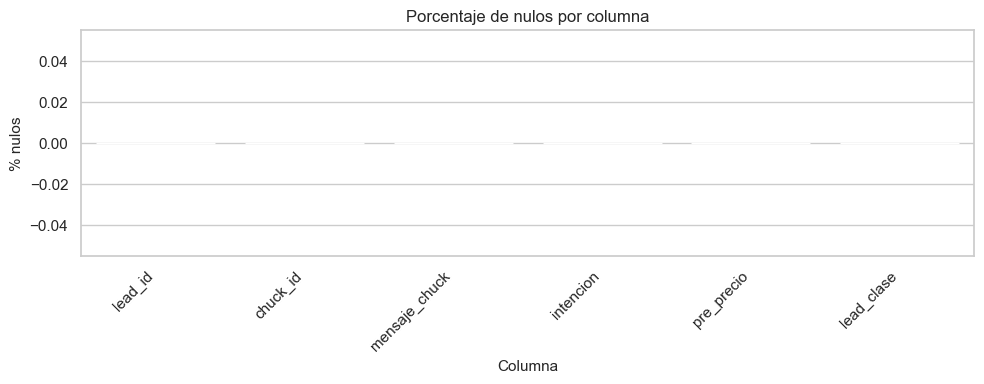

In [8]:
num_cols = df_clean.select_dtypes(include=["number", "Int64", "float", "int"]).columns.tolist()
cat_cols = [c for c in df_clean.columns if c not in num_cols]

print("Columnas numéricas:", num_cols)
print("Columnas categóricas/no numéricas:", cat_cols)

if num_cols:
    display(df_clean[num_cols].describe(percentiles=[0.05, 0.5, 0.95]).T)
else:
    print("No se detectaron columnas numéricas.")

if cat_cols:
    display(df_clean[cat_cols].describe(include=["object", "string"]).T)

# % nulos por columna
null_pct = df_clean.isna().mean().sort_values(ascending=False) * 100
plt.figure(figsize=(10, 4))
ax = sns.barplot(x=null_pct.index, y=null_pct.values)
ax.set_title("Porcentaje de nulos por columna")
ax.set_ylabel("% nulos")
ax.set_xlabel("Columna")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "null_pct_por_columna.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Distribuciones de variables numéricas

Se grafican histogramas con KDE para variables numéricas. Si hay sesgo fuerte, se muestra una versión con transformación logarítmica $x' = \log(1+x)$.

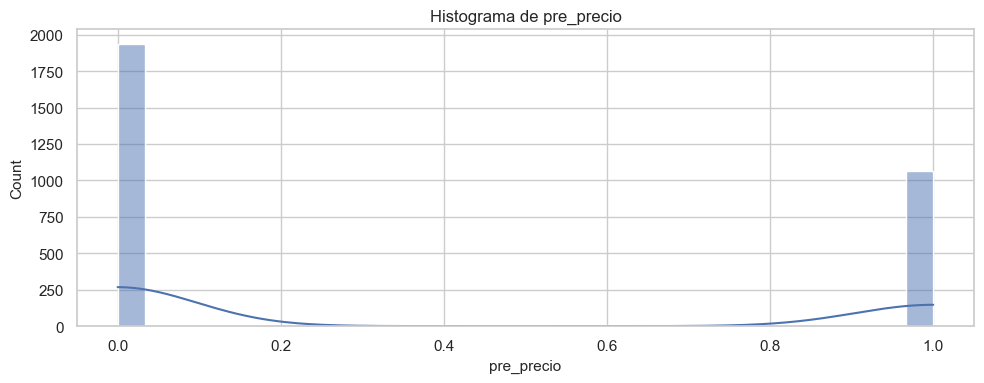

In [9]:
if not num_cols:
    print("No hay columnas numéricas para graficar.")
else:
    for col in num_cols:
        series = df_clean[col].dropna()
        if series.empty:
            continue

        plt.figure(figsize=(10, 4))
        sns.histplot(series, kde=True, bins=30)
        plt.title(f"Histograma de {col}")
        plt.tight_layout()
        plt.savefig(OUT_DIR / f"hist_{col}.png", dpi=150, bbox_inches="tight")
        plt.show()

        # Transformación log si aplica
        if (series >= 0).all() and series.nunique() > 10:
            plt.figure(figsize=(10, 4))
            sns.histplot(np.log1p(series), kde=True, bins=30)
            plt.title(f"Histograma log(1+x) de {col}")
            plt.tight_layout()
            plt.savefig(OUT_DIR / f"hist_log1p_{col}.png", dpi=150, bbox_inches="tight")
            plt.show()

## 8. Outliers en numéricas

Se usan boxplots y el criterio IQR.

$$\text{IQR}=Q_3-Q_1,\quad \text{lower}=Q_1-1.5\,\text{IQR},\quad \text{upper}=Q_3+1.5\,\text{IQR}$$

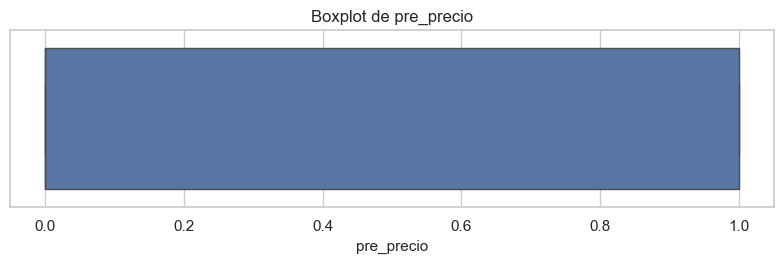

,columna,q1,q3,iqr,lower,upper,n_outliers
0,pre_precio,0.0,1.0,1.0,-1.5,2.5,0


In [10]:
outlier_rows = []

if not num_cols:
    print("No hay columnas numéricas para boxplots/outliers.")
else:
    # Boxplots
    for col in num_cols:
        series = df_clean[col].dropna()
        if series.empty:
            continue

        plt.figure(figsize=(8, 2.8))
        sns.boxplot(x=series)
        plt.title(f"Boxplot de {col}")
        plt.tight_layout()
        plt.savefig(OUT_DIR / f"box_{col}.png", dpi=150, bbox_inches="tight")
        plt.show()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        n_out = int(((series < lower) | (series > upper)).sum())

        outlier_rows.append(
            {
                "columna": col,
                "q1": float(q1),
                "q3": float(q3),
                "iqr": float(iqr),
                "lower": float(lower),
                "upper": float(upper),
                "n_outliers": n_out,
            }
        )

outliers_df = pd.DataFrame(outlier_rows)
display(outliers_df)

## 9. Análisis de variables categóricas

Se grafican conteos de las variables categóricas. En variables con alta cardinalidad se toman las top-N categorías y el resto se agrupa como `Otros`.

Categóricas detectadas: ['lead_id', 'chuck_id', 'mensaje_chuck', 'intencion', 'lead_clase']


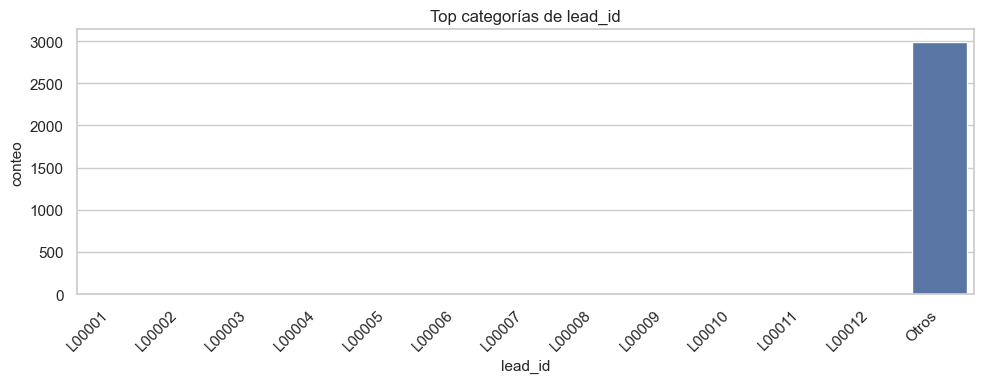

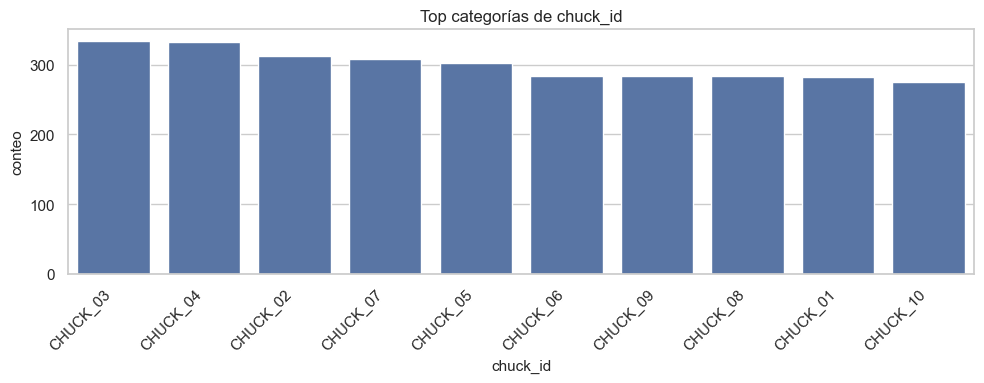

C:\Users\MARIANA\AppData\Local\Temp\ipykernel_4232\1712436972.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


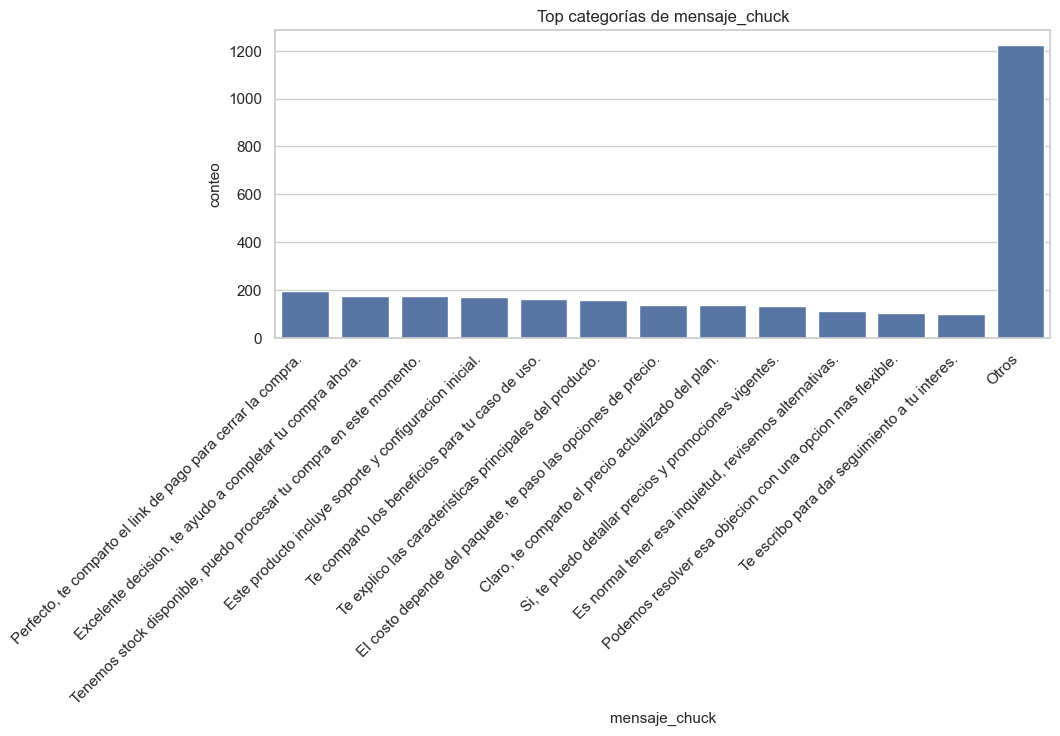

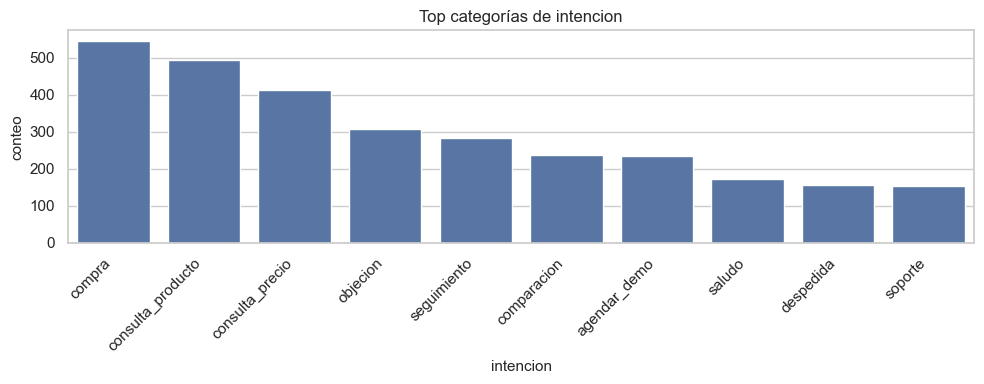

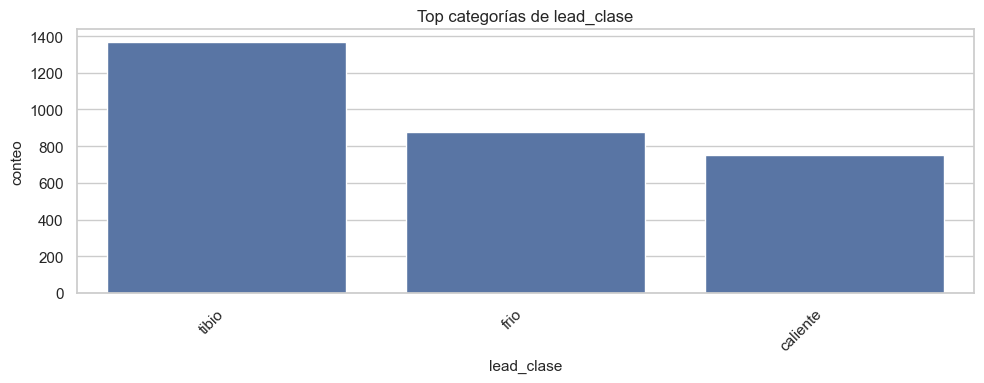

{'lead_id': lead_id
 L00001    0.000333
 L00002    0.000333
 L00003    0.000333
 L00004    0.000333
 L00005    0.000333
 L00006    0.000333
 L00007    0.000333
 L00008    0.000333
 L00009    0.000333
 L00010    0.000333
 L00011    0.000333
 L00012    0.000333
 L00013    0.000333
 L00014    0.000333
 L00015    0.000333
 Name: proportion, dtype: Float64,
 'chuck_id': chuck_id
 CHUCK_03    0.111333
 CHUCK_04       0.111
 CHUCK_02    0.104333
 CHUCK_07    0.102667
 CHUCK_05       0.101
 CHUCK_06    0.094667
 CHUCK_09    0.094667
 CHUCK_08    0.094667
 CHUCK_01       0.094
 CHUCK_10    0.091667
 Name: proportion, dtype: Float64,
 'mensaje_chuck': mensaje_chuck
 Perfecto, te comparto el link de pago para cerrar la compra.                0.065
 Excelente decision, te ayudo a completar tu compra ahora.                0.058667
 Tenemos stock disponible, puedo procesar tu compra en este momento.      0.058667
 Este producto incluye soporte y configuracion inicial.                   0.057333
 Te 

In [12]:
def plot_top_categories(data: pd.DataFrame, col: str, top_n: int = 10):
    s = data[col].astype("string")
    vc = s.value_counts(dropna=False)
    if len(vc) > top_n:
        top = vc.iloc[:top_n]
        other_count = vc.iloc[top_n:].sum()
        top = pd.concat([top, pd.Series({"Otros": other_count})])
    else:
        top = vc

    plt.figure(figsize=(10, 4))
    ax = sns.barplot(x=top.index.astype(str), y=top.values)
    ax.set_title(f"Top categorías de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("conteo")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"cat_top_{col}.png", dpi=150, bbox_inches="tight")
    plt.show()

cat_candidates = df_clean.select_dtypes(include=["object", "string"]).columns.tolist()
print("Categóricas detectadas:", cat_candidates)

for col in cat_candidates:
    plot_top_categories(df_clean, col, top_n=12)

# Proporciones por columna
prop_tables = {}
for col in cat_candidates:
    prop_tables[col] = df_clean[col].value_counts(normalize=True, dropna=False).head(15)

display({k: v for k, v in prop_tables.items()})

## 10. Relaciones bivariadas

Se exploran relaciones numéricas y categóricas:
- Num-Num: scatter para pares relevantes si existen.
- Cat-Num: boxplot por categoría.
- Cat-Cat: tablas de contingencia y heatmaps de proporciones.

No hay suficientes variables numéricas para scatterplots.


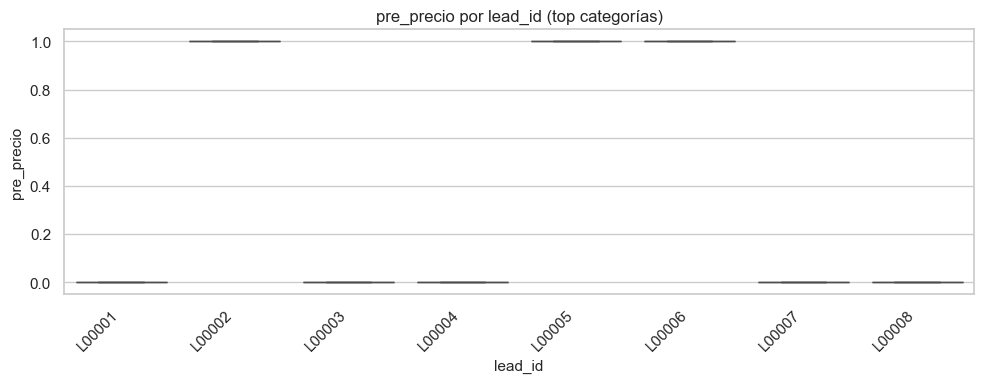

lead_clase,caliente,frio,tibio
intencion,,,
agendar_demo,0.346154,0.000000,0.653846
comparacion,0.277311,0.000000,0.722689
compra,0.804388,0.000000,0.195612
consulta_precio,0.402913,0.000000,0.597087
consulta_producto,0.000000,0.425101,0.574899
despedida,0.000000,1.000000,0.000000
objecion,0.000000,0.283388,0.716612
saludo,0.000000,1.000000,0.000000
seguimiento,0.000000,0.345070,0.654930


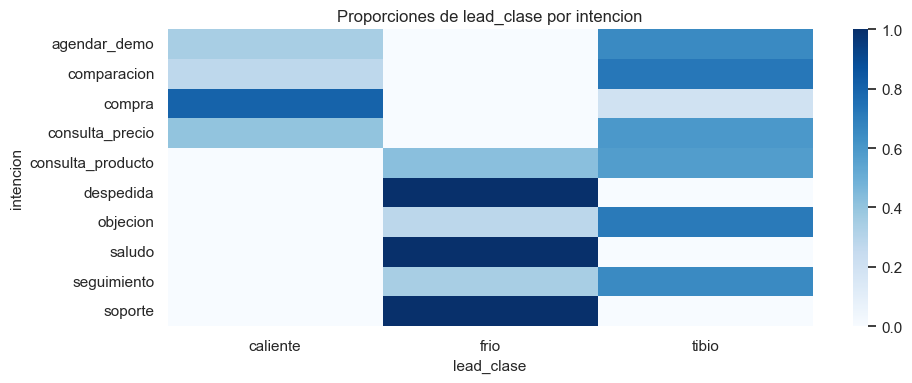

In [13]:
# Num-Num
if len(num_cols) >= 2:
    pairs = []
    for i in range(len(num_cols)):
        for j in range(i + 1, len(num_cols)):
            pairs.append((num_cols[i], num_cols[j]))

    for x, y in pairs[:3]:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(data=df_clean, x=x, y=y, alpha=0.6)
        plt.title(f"Scatter: {x} vs {y}")
        plt.tight_layout()
        plt.savefig(OUT_DIR / f"scatter_{x}_vs_{y}.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    print("No hay suficientes variables numéricas para scatterplots.")

# Cat-Num (si existen)
if num_cols and cat_candidates:
    num_for_cat = num_cols[0]
    cat_for_num = cat_candidates[0]

    top_cats = df_clean[cat_for_num].value_counts().head(8).index
    tmp = df_clean[df_clean[cat_for_num].isin(top_cats)].copy()

    plt.figure(figsize=(10, 4))
    sns.boxplot(data=tmp, x=cat_for_num, y=num_for_cat)
    plt.title(f"{num_for_cat} por {cat_for_num} (top categorías)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"box_{num_for_cat}_by_{cat_for_num}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Cat-Cat: intención vs clase, si existen
if {"intencion", "lead_clase"}.issubset(df_clean.columns):
    ct = pd.crosstab(df_clean["intencion"], df_clean["lead_clase"], normalize="index")
    display(ct)

    plt.figure(figsize=(10, 4))
    sns.heatmap(ct, annot=False, cmap="Blues")
    plt.title("Proporciones de lead_clase por intencion")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "heatmap_intencion_vs_lead_clase.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No se encuentran columnas 'intencion' y 'lead_clase' para crosstab.")

## 11. Correlaciones

Se calcula la correlación en variables numéricas y se grafica un heatmap. Se listan pares con correlación absoluta alta cuando existan suficientes variables.

In [14]:
if len(num_cols) < 2:
    print("No hay suficientes variables numéricas para correlación.")
else:
    corr = df_clean[num_cols].astype(float).corr()
    display(corr)

    plt.figure(figsize=(6 + 0.4 * len(num_cols), 5))
    sns.heatmap(corr, annot=False, cmap="vlag", center=0)
    plt.title("Matriz de correlación (Pearson)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "corr_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Pares con correlación alta
    corr_pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )
    high = corr_pairs[corr_pairs.abs() > 0.6]
    display(high.head(20))

No hay suficientes variables numéricas para correlación.


## 12. Ingeniería ligera para EDA

Se crean variables derivadas útiles para exploración, sin comprometer el dataset original:
- Parseo de fechas si existiesen.
- Bins para variables numéricas.
- Imputación simple solo para análisis exploratorio, dejando trazabilidad.

In [15]:
df_feat = df_clean.copy()

# Intento de parseo de fechas si existieran columnas con 'fecha' en el nombre
possible_date_cols = [c for c in df_feat.columns if "fecha" in c.lower()]
for col in possible_date_cols:
    parsed = pd.to_datetime(df_feat[col], errors="coerce")
    if parsed.notna().any():
        df_feat[col] = parsed
        df_feat[f"{col}_mes"] = parsed.dt.month
        df_feat[f"{col}_dow"] = parsed.dt.dayofweek

# Bins para alguna numérica representativa
if num_cols:
    col = num_cols[0]
    s = df_feat[col]
    if s.notna().sum() >= 20 and s.nunique(dropna=True) >= 4:
        try:
            df_feat[f"{col}_qbin"] = pd.qcut(s.astype(float), q=4, duplicates="drop")
        except Exception:
            df_feat[f"{col}_bin"] = pd.cut(s.astype(float), bins=4)

# Imputación simple para exploración
for col in df_feat.select_dtypes(include=["number", "Int64", "float", "int"]).columns:
    med = df_feat[col].median(skipna=True)
    df_feat[col] = df_feat[col].fillna(med)

for col in df_feat.select_dtypes(include=["object"]).columns:
    mode = df_feat[col].mode(dropna=True)
    if not mode.empty:
        df_feat[col] = df_feat[col].fillna(mode.iloc[0])

print("Columnas derivadas añadidas:")
added_cols = [c for c in df_feat.columns if c not in df_clean.columns]
display(added_cols)

display(df_feat.head())

Columnas derivadas añadidas:


[]

,lead_id,chuck_id,mensaje_chuck,intencion,pre_precio,lead_clase
0,L00001,CHUCK_04,"Excelente decision, te ayudo a completar tu co...",compra,0,tibio
1,L00002,CHUCK_01,"Claro, te comparto el precio actualizado del p...",consulta_precio,1,caliente
2,L00003,CHUCK_01,Retomo la conversacion para ayudarte con la de...,seguimiento,0,tibio
3,L00004,CHUCK_03,"Hola, un gusto saludarte. En que te asesoro?",saludo,0,frio
4,L00005,CHUCK_07,"El costo depende del paquete, te paso las opci...",consulta_precio,1,tibio


## 13. Segmentaciones y métricas por grupo

Se generan agregaciones con `groupby` y `pivot_table` para identificar patrones por `intencion`, `lead_clase` y `chuck_id` cuando existan.

Columnas de agrupación disponibles: ['lead_clase', 'intencion', 'chuck_id']


lead_clase
tibio       1368
frio         879
caliente     753
Name: count, dtype: Int64

lead_clase,caliente,frio,tibio
intencion,,,
agendar_demo,0.107570,0.000000,0.111842
comparacion,0.087649,0.000000,0.125731
compra,0.584329,0.000000,0.078216
consulta_precio,0.220452,0.000000,0.179825
consulta_producto,0.000000,0.238908,0.207602
despedida,0.000000,0.177474,0.000000
objecion,0.000000,0.098976,0.160819
saludo,0.000000,0.196815,0.000000
seguimiento,0.000000,0.111490,0.135965


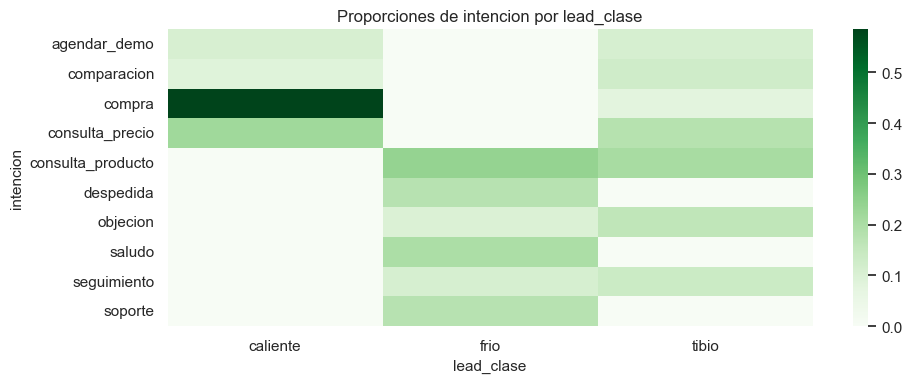

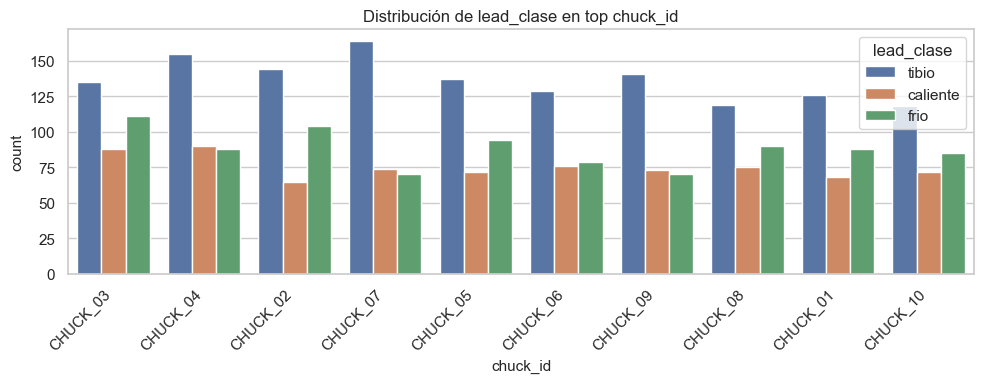

In [16]:
group_cols = [c for c in ["lead_clase", "intencion", "chuck_id"] if c in df_clean.columns]
print("Columnas de agrupación disponibles:", group_cols)

if "lead_clase" in df_clean.columns:
    display(df_clean["lead_clase"].value_counts(dropna=False))

if set(["intencion", "lead_clase"]).issubset(df_clean.columns):
    pivot = pd.crosstab(df_clean["intencion"], df_clean["lead_clase"], normalize="columns")
    display(pivot)

    plt.figure(figsize=(10, 4))
    sns.heatmap(pivot, cmap="Greens", annot=False)
    plt.title("Proporciones de intencion por lead_clase")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "heatmap_intencion_por_clase.png", dpi=150, bbox_inches="tight")
    plt.show()

if set(["chuck_id", "lead_clase"]).issubset(df_clean.columns):
    top_chucks = df_clean["chuck_id"].value_counts().head(10).index
    tmp = df_clean[df_clean["chuck_id"].isin(top_chucks)]

    plt.figure(figsize=(10, 4))
    sns.countplot(data=tmp, x="chuck_id", hue="lead_clase", order=top_chucks)
    plt.title("Distribución de lead_clase en top chuck_id")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "count_chuck_by_clase.png", dpi=150, bbox_inches="tight")
    plt.show()

## 14. Guardar artefactos

Las figuras se guardan automáticamente en `OUT_DIR`. Opcionalmente se exporta una versión limpia del dataset para pasos posteriores.

In [17]:
clean_out_path = OUT_DIR / "leads_3000_clean.csv"
df_clean.to_csv(clean_out_path, index=False)
print(f"Dataset limpio exportado a: {clean_out_path.resolve()}")

print("Listado de archivos generados en OUT_DIR:")
for p in sorted(OUT_DIR.glob("*.png"))[:20]:
    print("-", p.name)
if len(list(OUT_DIR.glob("*.png"))) > 20:
    print("...")

Dataset limpio exportado a: C:\Users\MARIANA\Desktop\LAIDA\algoritmos\outputs\leads_3000_clean.csv
Listado de archivos generados en OUT_DIR:
- box_pre_precio.png
- box_pre_precio_by_lead_id.png
- cat_top_chuck_id.png
- cat_top_intencion.png
- cat_top_lead_clase.png
- cat_top_lead_id.png
- cat_top_mensaje_chuck.png
- count_chuck_by_clase.png
- heatmap_intencion_por_clase.png
- heatmap_intencion_vs_lead_clase.png
- hist_pre_precio.png
- null_pct_por_columna.png


## Apéndice. EDA específico del dataset de leads

Este bloque agrega visualizaciones y métricas directamente alineadas a las columnas presentes en `leads_3000.csv`.

In [19]:
from IPython.display import display

expected_cols = {"lead_id", "chuck_id", "mensaje_chuck", "intencion", "pre_precio", "lead_clase"}
missing = expected_cols.difference(df_clean.columns)
if missing:
    raise ValueError(f"Faltan columnas esperadas en el CSV: {sorted(missing)}")

# Normalización ligera de algunas categóricas (preserva NA)
for col in ["intencion", "lead_clase", "chuck_id"]:
    df_clean[col] = df_clean[col].astype("string").str.strip().str.lower()

df_clean["pre_precio"] = df_clean["pre_precio"].astype("Int64")

display(df_clean.head())

,lead_id,chuck_id,mensaje_chuck,intencion,pre_precio,lead_clase
0,L00001,chuck_04,"Excelente decision, te ayudo a completar tu co...",compra,0,tibio
1,L00002,chuck_01,"Claro, te comparto el precio actualizado del p...",consulta_precio,1,caliente
2,L00003,chuck_01,Retomo la conversacion para ayudarte con la de...,seguimiento,0,tibio
3,L00004,chuck_03,"Hola, un gusto saludarte. En que te asesoro?",saludo,0,frio
4,L00005,chuck_07,"El costo depende del paquete, te paso las opci...",consulta_precio,1,tibio


### Distribuciones clave

Conteos de `lead_clase`, `intencion`, top `chuck_id` y la variable binaria `pre_precio`.

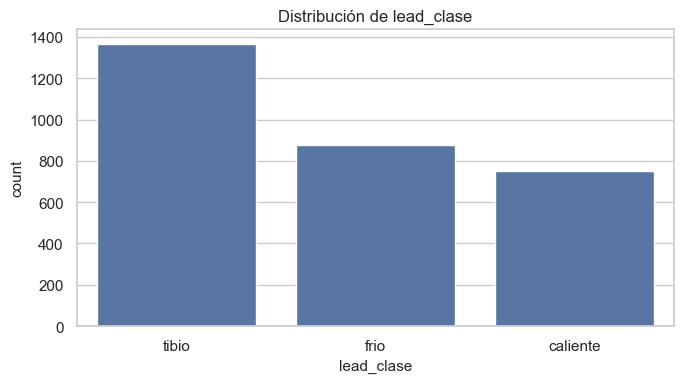

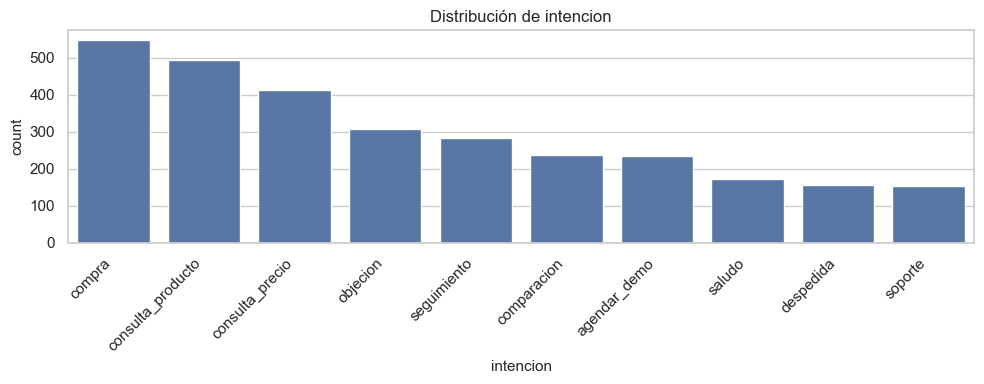

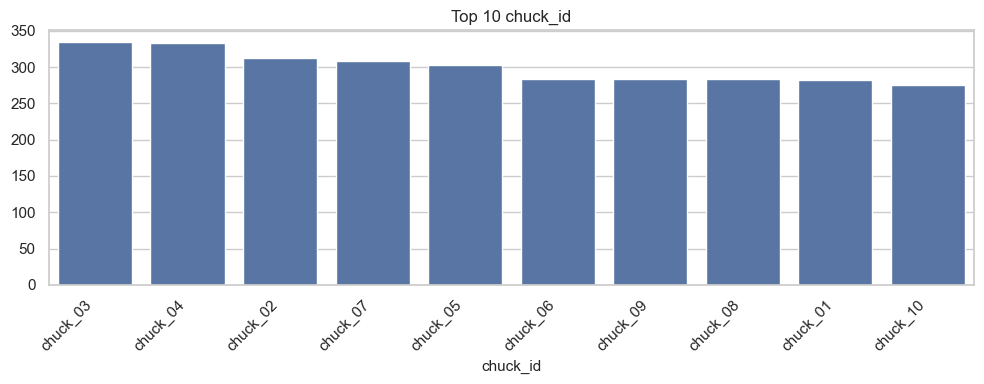

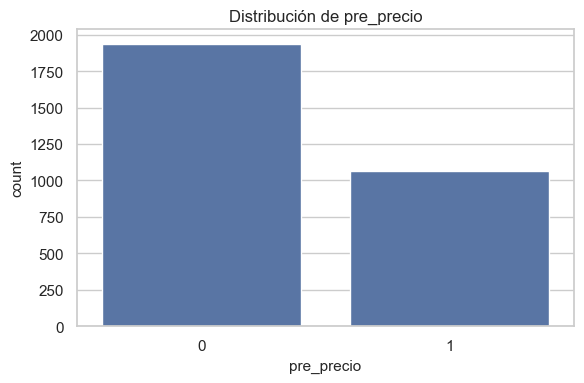

In [20]:
# lead_clase
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x="lead_clase", order=df_clean["lead_clase"].value_counts().index)
plt.title("Distribución de lead_clase")
plt.tight_layout()
plt.savefig(OUT_DIR / "count_lead_clase.png", dpi=150, bbox_inches="tight")
plt.show()

# intencion
plt.figure(figsize=(10, 4))
order_int = df_clean["intencion"].value_counts().index
sns.countplot(data=df_clean, x="intencion", order=order_int)
plt.title("Distribución de intencion")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "count_intencion.png", dpi=150, bbox_inches="tight")
plt.show()

# chuck_id top 10
plt.figure(figsize=(10, 4))
top_chuck = df_clean["chuck_id"].value_counts().head(10)
sns.barplot(x=top_chuck.index, y=top_chuck.values)
plt.title("Top 10 chuck_id")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "top10_chuck_id.png", dpi=150, bbox_inches="tight")
plt.show()

# pre_precio
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="pre_precio")
plt.title("Distribución de pre_precio")
plt.tight_layout()
plt.savefig(OUT_DIR / "count_pre_precio.png", dpi=150, bbox_inches="tight")
plt.show()

### Relaciones dirigidas

Cruces entre intención y clase, y entre `pre_precio` y `lead_clase`.

lead_clase,caliente,frio,tibio
intencion,,,
agendar_demo,0.346154,0.000000,0.653846
comparacion,0.277311,0.000000,0.722689
compra,0.804388,0.000000,0.195612
consulta_precio,0.402913,0.000000,0.597087
consulta_producto,0.000000,0.425101,0.574899
despedida,0.000000,1.000000,0.000000
objecion,0.000000,0.283388,0.716612
saludo,0.000000,1.000000,0.000000
seguimiento,0.000000,0.345070,0.654930


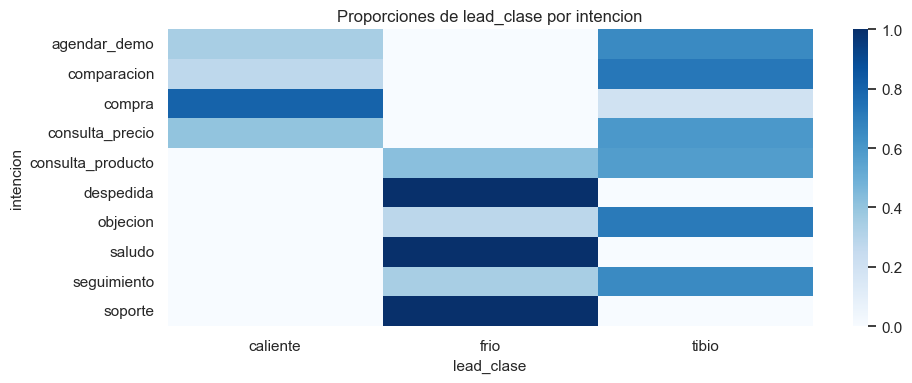

pre_precio,0,1
lead_clase,,
caliente,0.395750,0.604250
frio,0.894198,0.105802
tibio,0.625000,0.375000


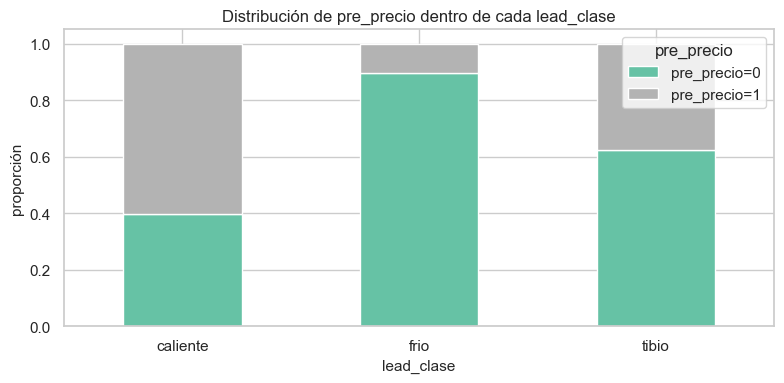

In [21]:
# intencion x lead_clase: proporciones por intención
ct_int = pd.crosstab(df_clean["intencion"], df_clean["lead_clase"], normalize="index")
display(ct_int)

plt.figure(figsize=(10, 4))
sns.heatmap(ct_int, cmap="Blues", annot=False)
plt.title("Proporciones de lead_clase por intencion")
plt.tight_layout()
plt.savefig(OUT_DIR / "heatmap_intencion_lead_clase_rownorm.png", dpi=150, bbox_inches="tight")
plt.show()

# pre_precio x lead_clase: barras apiladas porcentuales
ct_pp = pd.crosstab(df_clean["lead_clase"], df_clean["pre_precio"], normalize="index")
display(ct_pp)

ct_pp_plot = ct_pp.rename(columns={0: "pre_precio=0", 1: "pre_precio=1"})
ax = ct_pp_plot.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="Set2")
ax.set_title("Distribución de pre_precio dentro de cada lead_clase")
ax.set_xlabel("lead_clase")
ax.set_ylabel("proporción")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "stack_pre_precio_by_lead_clase.png", dpi=150, bbox_inches="tight")
plt.show()

### Análisis del texto `mensaje_chuck`

Se calculan longitudes del mensaje y se exploran distribuciones por clase. Luego se obtienen palabras más frecuentes con tokenización simple y una lista corta de stopwords en español.

,mensaje_chuck,len_chars,len_words,lead_clase
0,"Excelente decision, te ayudo a completar tu co...",57,9,tibio
1,"Claro, te comparto el precio actualizado del p...",50,8,caliente
2,Retomo la conversacion para ayudarte con la de...,53,8,tibio
3,"Hola, un gusto saludarte. En que te asesoro?",44,8,frio
4,"El costo depende del paquete, te paso las opci...",61,11,tibio


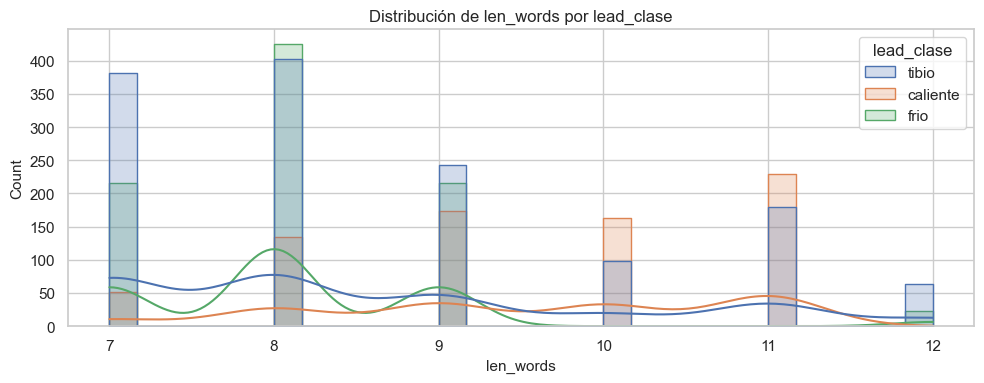

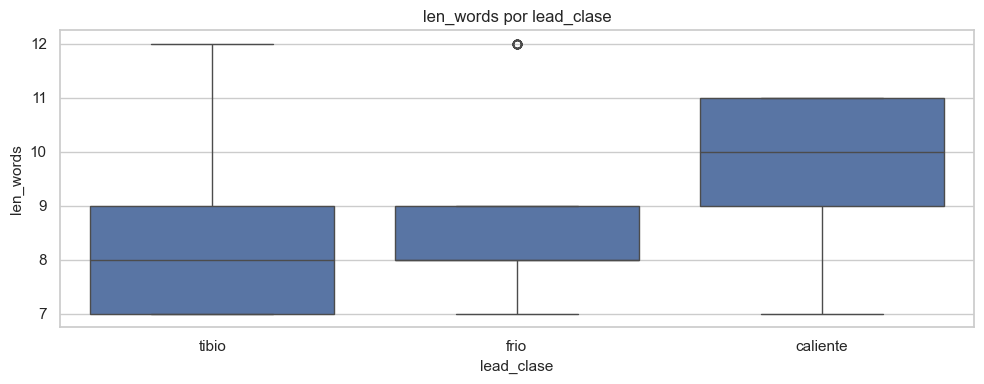

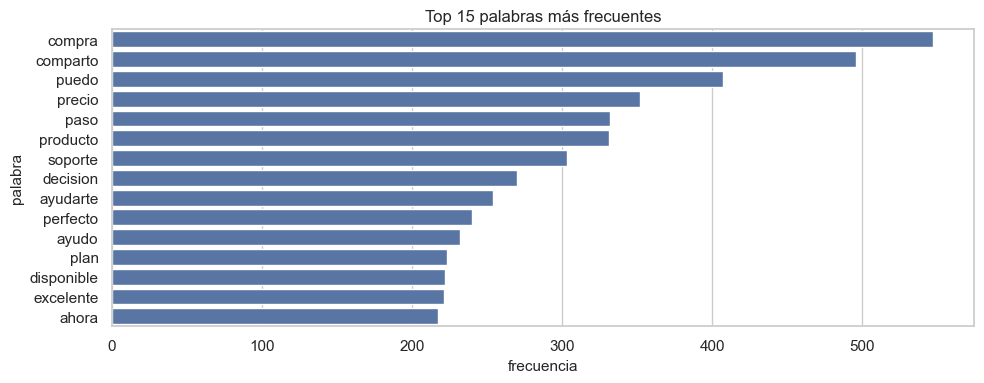

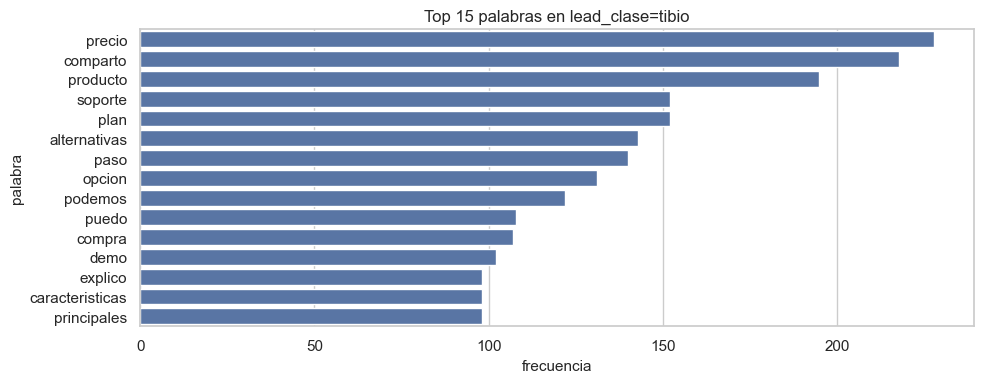

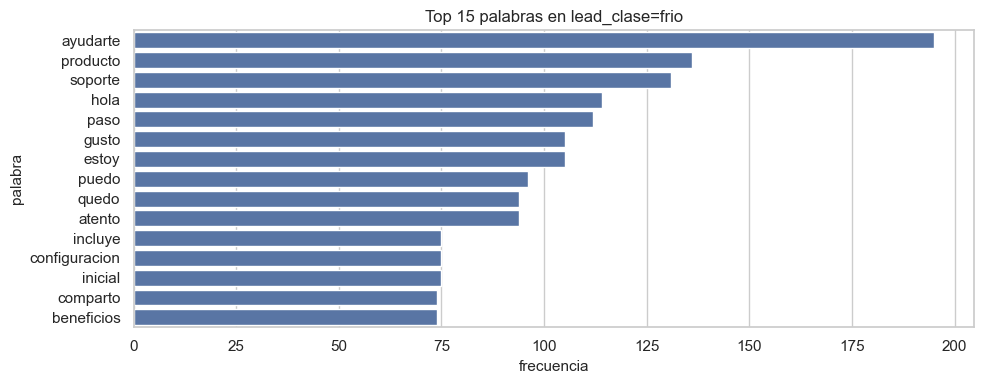

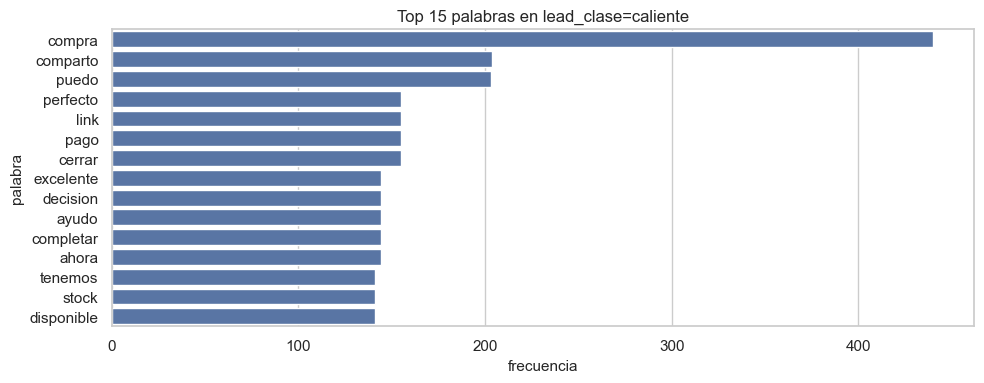

In [22]:
# Longitudes
msg = df_clean["mensaje_chuck"].fillna("").astype(str)
df_text = df_clean.copy()
df_text["len_chars"] = msg.str.len()
df_text["len_words"] = msg.apply(lambda x: len(re.findall(r"\b\w+\b", x.lower())))

display(df_text[["mensaje_chuck", "len_chars", "len_words", "lead_clase"]].head())

# Histogramas por lead_clase
plt.figure(figsize=(10, 4))
sns.histplot(data=df_text, x="len_words", hue="lead_clase", kde=True, bins=30, element="step")
plt.title("Distribución de len_words por lead_clase")
plt.tight_layout()
plt.savefig(OUT_DIR / "hist_len_words_by_clase.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(data=df_text, x="lead_clase", y="len_words", order=df_text["lead_clase"].value_counts().index)
plt.title("len_words por lead_clase")
plt.tight_layout()
plt.savefig(OUT_DIR / "box_len_words_by_clase.png", dpi=150, bbox_inches="tight")
plt.show()

# Frecuencias de palabras
stopwords = {
    "a","al","algo","algunas","algunos","ante","antes","aqui","as","asi","aun",
    "bajo","bien","cada","casi","como","con","contra","cual","cuando","de","del",
    "desde","donde","dos","el","ella","ellas","ellos","en","entre","era","es","esa",
    "ese","eso","esta","este","esto","estos","fue","ha","hasta","hay","la","las",
    "le","les","lo","los","mas","me","mi","mis","muy","no","nos","o","para","pero",
    "por","porque","que","se","si","sin","sobre","su","sus","te","tu","tus","un",
    "una","uno","unos","unas","y","ya","yo","tu","usted","ustedes","gracias"
}

def tokenize(text: str) -> list[str]:
    tokens = re.findall(r"\b\w+\b", text.lower())
    tokens = [t for t in tokens if t not in stopwords and len(t) > 2]
    return tokens

all_tokens = []
for t in msg.tolist():
    all_tokens.extend(tokenize(t))

freq = pd.Series(all_tokens).value_counts().head(15)
plt.figure(figsize=(10, 4))
sns.barplot(x=freq.values, y=freq.index)
plt.title("Top 15 palabras más frecuentes")
plt.xlabel("frecuencia")
plt.ylabel("palabra")
plt.tight_layout()
plt.savefig(OUT_DIR / "top_words_global.png", dpi=150, bbox_inches="tight")
plt.show()

# Top palabras por clase
for clase in df_text["lead_clase"].value_counts().index:
    tokens_c = []
    for t in df_text.loc[df_text["lead_clase"] == clase, "mensaje_chuck"].fillna("").astype(str).tolist():
        tokens_c.extend(tokenize(t))
    if not tokens_c:
        continue
    freq_c = pd.Series(tokens_c).value_counts().head(15)

    plt.figure(figsize=(10, 4))
    sns.barplot(x=freq_c.values, y=freq_c.index)
    plt.title(f"Top 15 palabras en lead_clase={clase}")
    plt.xlabel("frecuencia")
    plt.ylabel("palabra")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"top_words_{clase}.png", dpi=150, bbox_inches="tight")
    plt.show()

## Conclusiones

Se generan conclusiones basadas en los resultados observados al ejecutar el notebook, evitando reportar métricas no verificadas.

In [23]:
conclusions = []

# Clase más frecuente
most_class = df_clean["lead_clase"].value_counts().index[0]
conclusions.append(f"La clase más frecuente en el dataset fue '{most_class}'.")

# Intenciones más frecuentes
top_int = df_clean["intencion"].value_counts().head(3).index.tolist()
conclusions.append(f"Las intenciones más recurrentes estuvieron entre: {', '.join(top_int)}.")

# Efecto de pre_precio por clase (sin números)
ct_pp = pd.crosstab(df_clean["lead_clase"], df_clean["pre_precio"], normalize="index")
if 1 in ct_pp.columns and 0 in ct_pp.columns:
    clase_max = (ct_pp[1] - ct_pp[0]).sort_values(ascending=False).index[0]
    conclusions.append(f"La señal 'pre_precio=1' se observó relativamente más asociada a la clase '{clase_max}' que al resto.")

# Diferencias de longitud de mensaje por clase
med_words = df_text.groupby("lead_clase")["len_words"].median().sort_values(ascending=False)
clase_long = med_words.index[0]
clase_short = med_words.index[-1]
if clase_long != clase_short:
    conclusions.append(f"La longitud típica del mensaje varió por clase, con '{clase_long}' tendiendo a mensajes más largos que '{clase_short}'.")

# Palabras frecuentes
if not freq.empty:
    conclusions.append("Las palabras más frecuentes reflejaron patrones de conversación orientados a soporte, precio y cierre, útiles para feature engineering de texto.")

# Calidad de datos
if df.isna().sum().sum() == 0:
    conclusions.append("No se observaron nulos en el archivo original, aunque se mantuvo la normalización de strings como práctica defensiva.")
else:
    conclusions.append("Se detectaron nulos en el archivo original, por lo que conviene definir reglas de imputación y validación antes de modelar.")

# Mostrar 5 a 8 bullets
conclusions = conclusions[:8]

for c in conclusions:
    print("-", c)

- La clase más frecuente en el dataset fue 'tibio'.
- Las intenciones más recurrentes estuvieron entre: compra, consulta_producto, consulta_precio.
- La señal 'pre_precio=1' se observó relativamente más asociada a la clase 'caliente' que al resto.
- La longitud típica del mensaje varió por clase, con 'caliente' tendiendo a mensajes más largos que 'tibio'.
- Las palabras más frecuentes reflejaron patrones de conversación orientados a soporte, precio y cierre, útiles para feature engineering de texto.
- No se observaron nulos en el archivo original, aunque se mantuvo la normalización de strings como práctica defensiva.
